# 1. Прореживание глобальной выборки нуклеотидных последовательностей с группировкой по локации и году с использованием CD-HIT.
Цель - сократить выборку до репрезентативного набора последовательностей, сохраняя генетическое разнообразие внутри каждой временно-географической группы.

**Важно❗** Код работает только с заголовками формата Isolate name | Type | Segment | Collection date | Isolate ID | Clade  | Lineage.

Например: **A/goose/Guangdong/08/2005|A_/_H5N1|HA|2005-01-01|EPI_ISL_138867|2.3.4|**

⚡Логика поиска локации: это часть лейбла, указанная после второго разделителя "/", строго не содержащая ни одной цифры.
Изоляты, выделенные от человека, имеют формат: **A/Wyoming/01/2025|A_/_H5N1|HA|02/11/2025|EPI_ISL_19749443|2.3.4.4b|**, в таком случае после 2го разделителя идет код изолята, содержащий цифры и скрипт переходит к части после первого разделителя. Если она не содержит цифр то принимается за локацию. Если содержит то изолят попадает в группу Unknown по локации и не участвует в прореживании.

⚡Логика поиска года: это четырехзначное число, идущее ПЕРЕД первым вертикальным разделителем "|". Если там значение пропущено то скрипт переходит к части после третьего вертикального разделителя и вытаскивает 4х значное число оттуда.


**Примеры ошибок:**

Случается, что по каким-то причинам извлечь локацию или год не получилось (чаще всему проблема в нестандартных разделителях, например A_herring_gull_Latvia_287263_21VIR8325-5_2021|A_/_H5N1|HA|2021-05-30|EPI_ISL_18458053|2.3.4.4b|). Такие последовательности попадают в группу Unknown и не подлежат фильтрации: "⚪ Группа Unknown_2021: пропущена (сохранено без изменений: 3 шт.)" Список таких заголовков выводится в конце.


В выборке H5N1 2020-2026 в такие группы попадало менее 2% от общего числа, однако рекомендуем тщательно проверять выходные данные.

In [ ]:
# @markdown ### ⚙️ Установка и импорт библиотек
выполнить_установку = True  # @param {type:"boolean"}

if выполнить_установку:
    print("Установка библиотек...")
    !pip install biopython
    !apt-get install -y cd-hit

    import os
    import re
    import subprocess
    from Bio import SeqIO
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord

    print("Установка завершена!")
else:
    print("Установка пропущена")

In [ ]:
# @markdown ### 📂 Загрузка файла
# @markdown Нажмите кнопку "Choose File" и выберите ваш FASTA-файл

from google.colab import files

загрузить_файл = True  # @param {type:"boolean"}

if загрузить_файл:
    uploaded = files.upload()

    # Получаем имя первого загруженного файла
    input_file = list(uploaded.keys())[0] if uploaded else None

    if input_file:
        print(f"Файл загружен: {input_file}")
    else:
        print("Файл не выбран")


In [ ]:
def cdhit_deduplicate(input_file, threshold, word_size, download_result=False, output_name=None):

    # Проверка наличия cd-hit-est в системе
    if subprocess.run(["which", "cd-hit-est"], stdout=subprocess.DEVNULL).returncode != 0:
        print("🛑 Ошибка: cd-hit-est не установлен в системе! Выполните: !apt-get install cd-hit")
        return

    if not os.path.exists(input_file):
        print(f"🛑 Ошибка: Файл {input_file} не найден!")
        return

    records = list(SeqIO.parse(input_file, "fasta"))
    unknown_headers = []
    grouped_data = {}
    print(f"Шаг 1: Чтение файла. Найдено всего последовательностей: {len(records)}")
    print("Группировка последовательностей по локации и году...")

    for rec in records:
        desc = rec.description.strip()
        location, year = "Unknown", "Unknown"

        # Разрезаем заголовок по вертикальной черте
        main_parts = desc.split('|')
        strain_name = main_parts[0].strip().lstrip('>')

        # Делим лейбл по слэшам '/'
        virus_name_parts = [p.strip() for p in strain_name.split('/') if p.strip()]

        if len(virus_name_parts) >= 3:
            # 1. ПОИСК ЛОКАЦИИ
            loc_candidate = virus_name_parts[2] # Элемент после второго слэша

            # Если элемент после второго слэша содержит цифры (то вероятно это человеческий изолят и у него локация идет сразу после первого разделителя)
            if re.search(r'\d', loc_candidate):
                first_slash_elem = virus_name_parts[1] # Элемент после первого слэша

                # Если и там только цифры (или пустая строка/спецсимволы из цифр)
                if first_slash_elem.isdigit() or re.match(r'^[\d_-]+$', first_slash_elem):
                    location = "Unknown"
                else:
                    location = first_slash_elem
            else:
                # Если цифр во втором элементе нет, берем его как обычно
                location = loc_candidate

            #2. ПОИСК ГОДА
            year_candidate = virus_name_parts[-1]
            year_match = re.search(r'(\d{4}|\d{2})', year_candidate)

            if year_match:
                found_digits = year_match.group(1)
                year = found_digits if len(found_digits) == 4 else f"20{found_digits}"

            # Резервный поиск года в блоке даты (после 3го "|")
            if year == "Unknown" and len(main_parts) >= 4:
                backup_year_match = re.search(r'\b(\d{4})\b', main_parts[3].strip())
                if backup_year_match:
                    year = backup_year_match.group(1)

        # Если локация или год не определились
        if location == "Unknown" or year == "Unknown":
            unknown_headers.append(rec.description)
            if location == "Unknown":
                location = "Unknown"

        # заменяем все подозрительные символы на "_" для удобства работы
        raw_key = f"{location}_{year}"
        key = re.sub(r'[^a-zA-Z0-9_-]', '_', raw_key)
        key = re.sub(r'_+', '_', key).strip('_')

        if key not in grouped_data:
            grouped_data[key] = []
        grouped_data[key].append(rec)

    final_records = []

    print("\nШаг 2: Запуск кластеризации CD-HIT-EST:")
    for key, group in grouped_data.items():
        if not group:
            continue

        # создаем переменные имен файлов
        temp_input = f"temp_in_{key}.fasta"
        temp_output = f"temp_out_{key}.fasta"

        #если имя группы содержит Unknown - сохраняем как есть
        if "Unknown" in key:
            print(f" ⚪ Группа {key}: пропущена (сохранено без изменений: {len(group)} шт.)")
            final_records.extend(group)
            continue

        clean_group = []
        for rec in group:
            raw_seq = str(rec.seq).replace("-", "").upper()
            if len(raw_seq) > 10:
                clean_rec = SeqRecord(Seq(raw_seq), id=rec.id, description="")
                clean_group.append(clean_rec)

        if not clean_group:
            print(f" ⚠️ Группа {key}: ошибка, проверьте выравнивание")
            continue

        # Запись очищенной группы во временный файл
        SeqIO.write(clean_group, temp_input, "fasta")

        # список аргументов
        cmd = [
            "cd-hit-est",
            "-i", temp_input,
            "-o", temp_output,
            "-c", str(threshold),
            "-n", str(word_size),
            "-d", "0",
            "-M", "0",
            "-T", "0"
        ]

        result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

        # Проверяем успешность создания выходного файла
        if os.path.exists(temp_output) and os.path.getsize(temp_output) > 0:

            # Читаем ID, которые CD-HIT выбрал как уникальные
            unique_ids = {rec.id for rec in SeqIO.parse(temp_output, "fasta")}

            # Находим эти записи среди исходника и добавляем в итог
            cleaned_group = [rec for rec in group if rec.id in unique_ids]
            final_records.extend(cleaned_group)

            if len(cleaned_group) < len(clean_group):
                print(f" 🟢 Группа {key}: сокращена (было {len(clean_group)}, стало {len(cleaned_group)})")
            else:
                print(f" ⚪ Группа {key}: не изменилась (сохранено: {len(clean_group)})")
        else:
            # Если CD-HIT не сработал:
            final_records.extend(clean_group)
            stdout_text = result.stdout.decode('utf-8', errors='ignore')
            stderr_text = result.stderr.decode('utf-8', errors='ignore')
            log_error = stderr_text.strip() or stdout_text.strip()[:50]
            print(f" ⚠️ Группа {key}: ошибка CD-HIT ({len(clean_group)} шт.) | Log: {log_error}")

        # Удаление временных файлов
        for f in [temp_input, temp_output, f"{temp_output}.clstr"]:
            if os.path.exists(f):
                os.remove(f)
    if unknown_headers:
        print(f"⚠️ ОБНАРУЖЕНО {len(unknown_headers)} ПОСЛЕДОВАТЕЛЬНОСТЕЙ С НЕОПРЕДЕЛИВШЕЙСЯ ЛОКАЦИЕЙ/ГОДОМ (сохранены без изменений):")
    for header in unknown_headers:
        print(f"  • {header}")

       # Если имя не указано - создаем автоматическое
    if not output_name:
        base_name = os.path.splitext(os.path.basename(input_file))[0]
        output_name = f"{len(final_records)}__{base_name}.fasta"
    else:
        # добавляем .fasta если его нет в имени файла
        if not output_name.endswith('.fasta') and not output_name.endswith('.fa'):
            output_name = output_name + '.fasta'

    SeqIO.write(final_records, output_name, "fasta")
    print(f"\n ИТОГ: {len(final_records)} ✅ последовательностей успешно обработано и сохранено в {output_name}")

    if download_result:
        from google.colab import files
        print(f"Скачивание файла {output_name}...)")
        files.download(output_name)

        #интерфейс:

#@markdown ☘️ Введите имя вашего FASTA-файла и выберите порог идентичности:
input_file = "" #@param {type:"string"}
threshold = 0.995 #@param {type:"slider", min:0.9, max:1.0, step:0.001}

#@markdown введите название результата (если оставить пустым - название будет в формате "количество последовательностей после фильтрации__исходное название")
output_name = ""  # @param {type:"string"}

# скачивание:
скачать_результат_автоматически = True #@param {type:"boolean"}


word_size = 9 #@param [5, 6, 7, 8, 9, 10, 11] {type:"raw"}
#@markdown *подходящую длину слова смотрите в cdhit-users-guide.pdf

# Запуск функции с передачей всех параметров из интерфейса
cdhit_deduplicate(
    input_file=input_file,
    threshold=threshold,
    word_size=word_size,
    download_result=скачать_результат_автоматически,
    output_name=output_name
)

# 2. Вывод локаций на карту мира 🗺️
Цель - определить зону циркуляции выявленных кластеров.

***Итак, вы построили филогенетическое дерево по сбалансированной выборке и выявили ряд филогеографических кластеров. Теперь визуализирум полученные данные на карте мира.***

С помощью следующей ячейки можно извлечь список локаций из списка лейблов, скопированного из любого источника.
Обратите внимание, что каждый лейбл должен начинаться с обозначения типа вируса со слэшем (например, "A/"). Логика поиска локации такая же, как в пункте 1. За локацию принимаем часть после 2го слэша, не содержащую ни одной цифры. Если эта часть содержит цифры, то алгоритм переходит на часть после первого слэша и выводит локацию оттуда. Если же обе части содержат цифры, то выводится полный лейбл этого изолята для ручной проверки

In [ ]:
#@markdown **Вывод списка локаций из кластера (формат json)** { display-mode: "form" }
import json
import re

#@markdown Скопируйте все лейблы выявленного кластера (например из MEGA) и вставьте ниже:
raw_data = "" #@param {type:"string", widget:"textarea"}

# 1. Выпадающий список для выбора типа гриппа
virus_type = "A" # @param ["A","B","C","D"]
#@markdown укажите тип вируса гриппа в окошке virus_type, это нужно для корректногой работы алгоритма

def extract_locations(text):
    locations = set()

    # 2. Подставляется выбранный тип гриппа
    lines = re.findall(rf'({virus_type}/.*?)(?={virus_type}/|$)', text)
    locations = set()
    bad_locations_lines = []  # Список для полных лейблов с ошибочными локациями (где есть хоть одна цифра)

    for line in lines:
        cleaned_line = line.strip()
        if not cleaned_line:
            continue

        # 1. Забираем имя штамма до первой вертикальной черты '|'
        name_part = cleaned_line.split('|')[0].strip()
        parts = [p.strip() for p in name_part.split('/') if p.strip()]

        if len(parts) >= 3:
            # Кандидат №1: элемент после второго слэша (индекс 2)
            loc_candidate = parts[2]

            # Если элемент после второго слэша содержит хотя бы одну цифру
            if re.search(r'\d', loc_candidate):
                final_loc = parts[1]  # Переключились на элемент после первого слэша (индекс 1)

                # если и в элементе после первого слэша есть хоть одна цифра
                if re.search(r'\d', final_loc):
                    bad_locations_lines.append(cleaned_line)  # Сохраняем полный лейбл
                    continue  # Полностью пропускаем этот лейбл, не выводим локацию
            else:
                # Если цифр во втором элементе нет:
                final_loc = loc_candidate

            # 2. Добавляем в итоговый список только текстовые локации
            if final_loc:
                locations.add(final_loc)

    # Создаем отсортированный список уникальных локаций
    cities_list = sorted(list(locations))

    # Возвращаем JSON-строку и список ошибок для вывода
    return json.dumps(cities_list, ensure_ascii=False), bad_locations_lines


# ВЫВОД РЕЗУЛЬТАТОВ:
json_result, bad_lines = extract_locations(raw_data)

# 1. Сначала выводим JSON-массив
print(json_result)

# 2. Выводим полные лейблы с непонятной локацией
if bad_lines:
    print(f"\n⚠️ список лейблов, откуда не удалось вывести локацию:")
    for bad_line in bad_lines:
        print(f"  • {bad_line}")


⚠️**Внимание! Здесь и далее ЛОКАЦИЯ НЕ ДОЛЖНА СОДЕРЖАТЬ ВНУТРЕННИХ ЗАПЯТЫХ! ВСЕ, ЧТО ОТДЕЛЕНО ЗАПЯТОЙ, ЧИТАЕТСЯ КАК ОТДЕЛЬНАЯ ЛОКАЦИЯ**


In [ ]:
import json

# @markdown **Ячейка для поиска локаций, где пересекаются изучаемые вами генетические линии.** <br><br>Вставьте элементы первого списка:
список_1 = "" # @param {type:"string"}

# @markdown Вставьте элементы второго списка:
список_2 = "" # @param {type:"string"}

# Переводим текст из окошек в чистые списки Python
def clean_input_to_list(raw_string):
    # Убираем кавычки и скобки, если они были введены пользователем
    clean_str = raw_string.replace("[", "").replace("]", "").replace('"', '').replace("'", "")
    # Делим по запятым и убираем лишние пробелы вокруг слов
    return [item.strip() for item in clean_str.split(",") if item.strip()]

list_a = clean_input_to_list(список_1)
list_b = clean_input_to_list(список_2)

# Находим общие локации через пересечение множеств
common_locations = list(set(list_a) & set(list_b))

# Сортируем для красоты по алфавиту
common_locations.sort()

# Переводим список в формат JSON-строки
output_in_double_quotes = json.dumps(common_locations, ensure_ascii=False)

# Выводим результат на экран
print("Общие локации:")
print(output_in_double_quotes)


🗺️ **В следующей ячейке наконец можно построить карту циркуляции интересующих вас кластеров.**

Локации можно вносить в любом формате, главное использовать **запятые только в качестве разделителей** между локациями. Пример ввода данных: Akita, о. Итуруп (Сахалинская область; Россия), "Bangladesh" и т.п

💡 Обратите внимание - интерактивные карты можно выгрузить в формате html, при наведении курсора на локацию можно будет увидеть название локации и название группы, которое вы ввели в сответствующем окошке.

💡 Если выводите на карту несколько кластеров - показывайте их область пересечения (список формируете в предыдущем коде) другим цветом (например, кластер 1 - green, 2 - blue, пересечение - cadetblue)

💡 Если вы хотите посмотреть как будет выглядеть карта без определенной группы - просто поставьте значок ***"#"*** в начале строки с перечнем локаций. Например: ***#***"Akita", "Alaska", "Aomori"...

💡 Если вам нужно представить динамику кластера по определенным временным промежуткам - можно сформировать соответствующие списки локаций и показать их разными оттенкам и одного цвета.

**ВАЖНО❗ внимательно проверяйте, как локации вывелись на карту.** Сервис геокодирования распознает многие локации не так, как хотелось бы. При сомнениях проверяйте соответствие локации изолята информации о нем в базе данных.

Например, топоним Kochi встречается как в Индии, так и в Японии. Находим исходный лейбл откуда взята локация: A/peregrine_falcon/Kochi/3911C002/2023|A_/_H5N1|HA|2023-11-21|EPI_ISL_19496400|2.3.4.4b - в GISAID отмечено, что этот изолят выделен именно в Японии (Japan / Kochi). Соответственно для корректного вывода на карту исправляем -  заменяем "Kochi" на "Japan Kochi"

**Еще из стандартных ошибок:**

Двубуквенные сокращения штатов США часто выводятся на карту в неожиданных местах. Например, SK может определяться в Словакии или даже Южной Корее. на самом же деле это Canada Saskatchewan. Приведем небольшой список локаций и их исправленных названий для корректного определения

PE - Prince Edward Island Canada

Simane (встречается как опечатка в Shimane) - Shimane Prefecture Japan

Iturup - Iturup Island Sakhalin Oblast Russia

Russia Tyuleniy - Tyuleniy Island Sea of Okhotsk

Henan - Henan China (с Zhejiang аналогично)

Kamchatka - Kamchatka Krai Russia

**для удобства отображения ячейки если работаете в google collab, подбирайте ширину экрана так, чтобы формы ввода данных конкретной группы располагались в один ряд:**
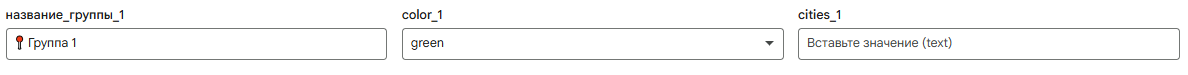

In [ ]:
#@title Интерактивная карта локаций { display-mode: "form" }
from geopy.geocoders import ArcGIS
import folium
import time
import json

название_группы_1 = "📍 Группа 1" #@param {type:"string"}
color_1 = "green" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_1 = "" #@param {type:"string", widget:"textarea"}

название_группы_2 = "📍 Группа 2" #@param {type:"string"}
color_2 = "blue" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_2 = "" #@param {type:"string", widget:"textarea"}

название_группы_3 = "📍 Группа 3" #@param {type:"string"}
color_3 = "cadetblue" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_3 = "" #@param {type:"string", widget:"textarea"}

название_группы_4 = "📍 Группа 4" #@param {type:"string"}
color_4 = "black" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_4 = "" #@param {type:"string", widget:"textarea"}

название_группы_5 = "📍 Группа 5" #@param {type:"string"}
color_5 = "gray" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_5 = "" #@param {type:"string", widget:"textarea"}

название_группы_6 = "📍 Группа 6" #@param {type:"string"}
color_6 = "lightgray" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_6 = "" #@param {type:"string", widget:"textarea"}


def parse_input_cities(raw_text):
    """извлекает список городов из любого формата (JSON или просто список)."""
    text = raw_text.strip()
    if not text:
        return []
    try:
        # Если вставили готовый JSON
        parsed = json.loads(text)
        if isinstance(parsed, dict) and "cities" in parsed:
            return parsed["cities"]
        elif isinstance(parsed, list):
            return parsed
    except:
        # 1. Сначала делим текст на чистые строки по переносам
        text = text.replace("\r\n", "\n").replace("\r", "\n")
        raw_lines = text.split("\n")

        # 2. Оставляем ТОЛЬКО те строки, которые НЕ начинаются с решетки #
        valid_lines = [line for line in raw_lines if not line.strip().startswith('#')]

        # 3. Соединяем обратно и очищаем от кавычек
        text = "\n".join(valid_lines)
        text = text.replace("[", "").replace("]", "").replace('"', '').replace("'", "")

        # 4. Возвращаем результат
        if "\n" in text:
            return [c.strip() for c in text.split("\n") if c.strip()]
        return [c.strip() for c in text.split(",") if c.strip()]
    return []


def create_colored_map(groups_dict):
    geolocator = ArcGIS(timeout=10)

    # Создаем базовую карту
    m = folium.Map(
        location=[30.0, 160.0],
        zoom_start=2,
        tiles='OpenStreetMap'
    )

    print("Использую сервис ArcGIS для поиска координат...\n")

    for group_name, info in groups_dict.items():
        color = info['color']
        cities = info['cities']

        if not cities:
            continue

        print(f"--- Обработка группы: {group_name} ({color}) ---")
        for city in cities:
            try:
                location = geolocator.geocode(city)
                if location:
                    # Исправлено: корректные параметры цвета для стандартной иконки folium
                    folium.Marker(
                        location=[location.latitude, location.longitude],
                        popup=f"Группа: {group_name}<br>Город: {city}",
                        tooltip=city,
                        icon=folium.Icon(color=color, icon='')
                    ).add_to(m)
                    print(f"✅ {city} -> {color}")
                else:
                    print(f"❌ {city} не найден")
                time.sleep(0.3)
            except Exception as e:
                print(f"⚠️ Ошибка с {city}: {e}")
                time.sleep(1)
    return m

# Сбор данных из интерактивных окон формы
my_groups = {
    название_группы_1: {"color": color_1, "cities": parse_input_cities(cities_1)},
    название_группы_2: {"color": color_2, "cities": parse_input_cities(cities_2)},
    название_группы_3: {"color": color_3, "cities": parse_input_cities(cities_3)},
    название_группы_4: {"color": color_4, "cities": parse_input_cities(cities_4)},
    название_группы_5: {"color": color_5, "cities": parse_input_cities(cities_5)},
    название_группы_6: {"color": color_6, "cities": parse_input_cities(cities_6)},
}

# Проверка на заполненность окон перед запуском
if any(my_groups[g]["cities"] for g in my_groups):
    map_res = create_colored_map(my_groups)
    # Отображаем карту прямо под формой
    display(map_res)
else:
    print("⚠️ Все окошки со списками локаций пусты. Пожалуйста, вставьте данные хотя бы в одно окно.")

import os
from google.colab import files

# 1. БЛОК НАСТРОЕК COLAB (ФОРМА)

# @markdown Введите название итогового файла карты:
output_name = ""  # @param {type:"string"}

скачать_результат_автоматически = False  # @param {type:"boolean"}
download_result = скачать_результат_автоматически

# 2. ИСПРАВЛЕНИЕ ИМЕНИ И СКАЧИВАНИЕ
# Убираем случайные пробелы по краям
output_name = output_name.strip()

# Если поле оставили абсолютно пустым, даем стандартное имя
if not output_name:
    output_name = "my_map.html"
else:
    # автоматически дописываем .html, если его нет в конце
    if not output_name.lower().endswith(".html"):
        output_name += ".html"

# Сохраняем карту на диск Colab под проверенным именем
try:
    map_res.save(output_name)
    print(f"✓ Карта успешно сохранена на диск Colab как '{output_name}'")

    # Если включена галочка, скачиваем готовый файл на компьютер
    if download_result:
        print(f"⏳ Начинаю автоматическое скачивание файла {output_name} на ваш компьютер...")
        files.download(output_name)

except NameError:
    print("❌ Ошибка: Карта 'map_res' не найдена! Убедитесь, что вы запустили ячейку, где создается карта.")
except Exception as e:
    print(f"❌ Произошла ошибка при сохранении/скачивании: {e}")
